<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 19 - Ejemplo 1 - Métodos de ensamble
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys


Se cuenta con un conjunto de datos meteorológicos compuesto por 2500 registros y 6 variables. El objetivo es desarrollar un modelo de aprendizaje automático supervisado capaz de predecir si lloverá o no a partir de ciertas condiciones climáticas.

La variable objetivo es Rain, la cual indica si hubo lluvia o no. Por lo tanto, el problema corresponde a una tarea de clasificación binaria.

Las variables disponibles en el conjunto de datos son:

| Variable | Descripción |
|---|---|
| Temperature | Temperatura registrada |
| Humidity | Nivel de humedad |
| Wind_Speed | Velocidad del viento |
| Cloud_Cover | Porcentaje o nivel de nubosidad |
| Pressure | Presión atmosférica |
| Rain | Variable objetivo que indica si llovió o no |

El propósito del análisis es entrenar y evaluar modelos de clasificación que permitan predecir la ocurrencia de lluvia. Para ello, se pueden utilizar algoritmos como regresión logística, árbol de decisión, random forest, bagging, pasting o gradient boosting.

1. Explorar inicialmente el conjunto de datos.
2. Identificar las variables predictoras y la variable objetivo.
3. Dividir los datos en conjunto de entrenamiento y conjunto de prueba.
4. Entrenar diferentes modelos de clasificación.
5. Evaluar los modelos utilizando métricas como accuracy, precisión, recall, F1-score y matriz de confusión.
6. Comparar los resultados obtenidos.
7. Seleccionar el modelo con mejor desempeño predictivo.

In [2]:
datos = pd.read_csv("weather_forecast_data.csv")

In [3]:
datos

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain
...,...,...,...,...,...,...
2495,21.791602,45.270902,11.807192,55.044682,1017.686181,no rain
2496,27.558479,46.481744,10.884915,39.715133,1008.590961,no rain
2497,28.108274,43.817178,2.897128,75.842952,999.119187,no rain
2498,14.789275,57.908105,2.374717,2.378743,1046.501875,no rain


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [5]:
datos["Lluvia"] = [1 if x=="rain" else 0 for x in datos["Rain"]]

In [6]:
datos

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain,Lluvia
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain,0
...,...,...,...,...,...,...,...
2495,21.791602,45.270902,11.807192,55.044682,1017.686181,no rain,0
2496,27.558479,46.481744,10.884915,39.715133,1008.590961,no rain,0
2497,28.108274,43.817178,2.897128,75.842952,999.119187,no rain,0
2498,14.789275,57.908105,2.374717,2.378743,1046.501875,no rain,0


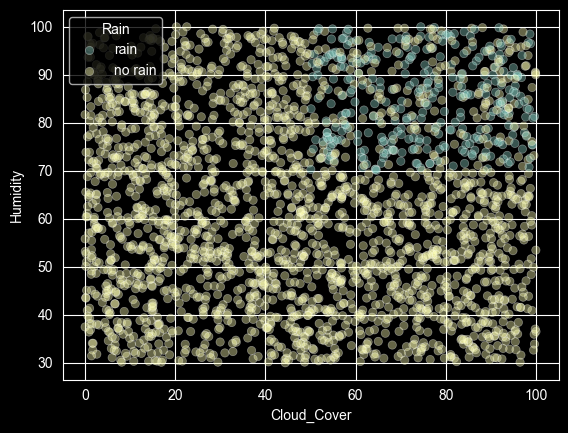

In [7]:
#1) Crear gráfico de dispersión clasificado por default
plt.figure()
sns.scatterplot(data=datos, x="Cloud_Cover", y="Humidity", hue ="Rain", alpha=0.4)
plt.show()

In [8]:
X_independientes = datos[["Cloud_Cover", "Humidity"]]
y_dependiente = datos["Lluvia"]

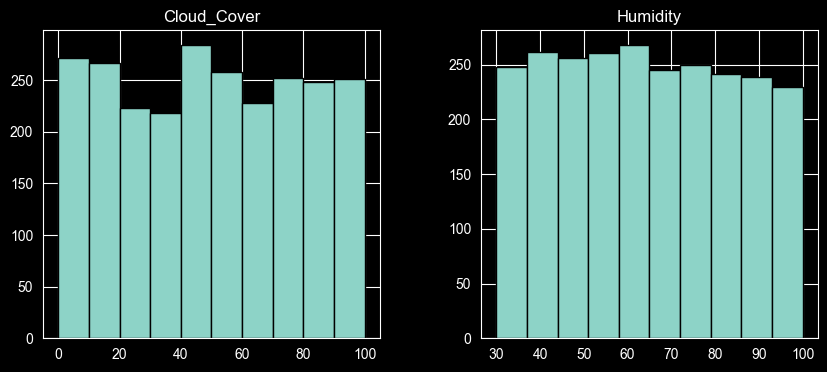

In [9]:
plt.figure()
X_independientes.hist(figsize = (10,4), edgecolor = 'black')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_independientes, y_dependiente, test_size=0.25, random_state=2026)

In [12]:
#Crear un árbol usando profundidad máxima de 4
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=4, random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train);

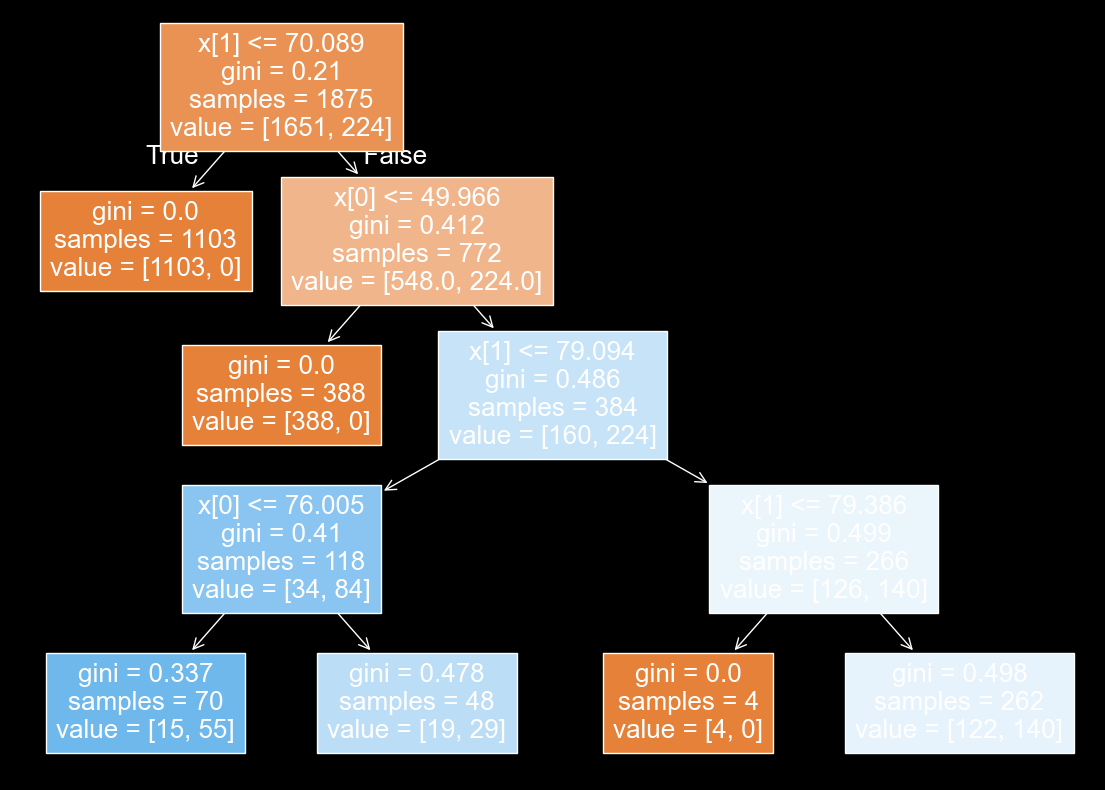

In [13]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf,filled=True)

In [14]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 0.944


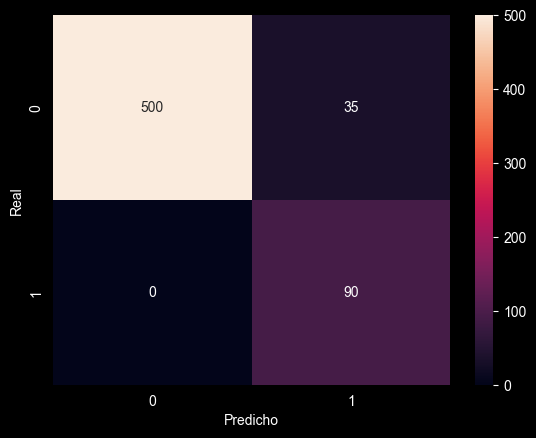

In [15]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_a = precision_score(y_test, y_pred_a)
recall_a = recall_score(y_test, y_pred_a)
f1_a = f1_score(y_test, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_a, recall_a,f1_a]})
metricas

,Métricas,Valores
0,Precisión,0.720000
1,Recall,1.000000
2,F1,0.837209


Se entrenó un modelo de árbol de decisión con una profundidad máxima de 4, obteniendo un accuracy score de 0.944, lo que indica que clasificó correctamente el 94.4% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.720000, un recall de 1.000000 y un F1-score de 0.837209. El recall perfecto muestra que el modelo identificó correctamente todos los casos positivos, es decir, todos los casos en los que sí llovió; sin embargo, la precisión indica que algunas predicciones positivas no fueron correctas, por lo que el modelo pudo clasificar ciertos días sin lluvia como días lluviosos. En general, el árbol de decisión presenta un desempeño favorable, especialmente si el objetivo principal es no dejar de detectar los días en los que realmente llueve.

In [17]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, alpha=0.5, contour=True):
    axes=[np.min(X.iloc[:, 0]), np.max(X.iloc[:, 0]), np.min(X.iloc[:, 1]), np.max(X.iloc[:, 1])]
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

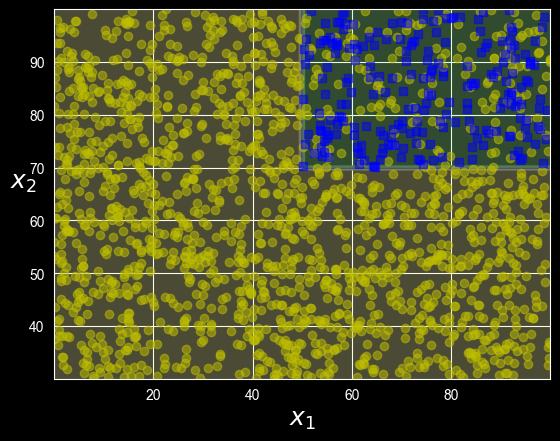

In [18]:
plot_decision_boundary(tree_clf, X_train, y_train, alpha=0.5, contour=True)

In [19]:
#Crear el modelo de bagging

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=True, random_state=2026)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",2026
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [20]:
#Obtener el accuracy_score
y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.9136


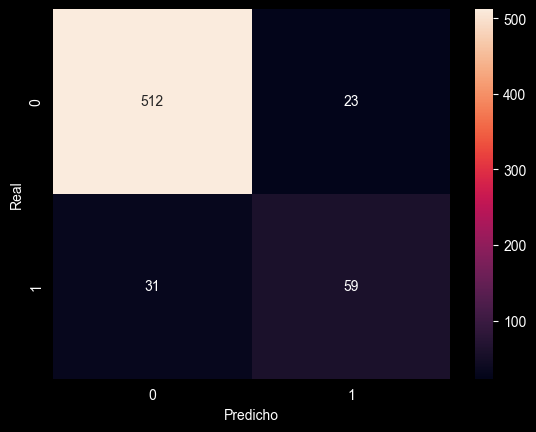

In [21]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_bag= precision_score(y_test, y_pred_bag)
recall_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_bag, recall_bag,f1_bag]})
metricas

,Métricas,Valores
0,Precisión,0.719512
1,Recall,0.655556
2,F1,0.686047


Se entrenó un modelo de bagging, obteniendo un accuracy score de 0.9248, lo que indica que clasificó correctamente el 92.48% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.736264, un recall de 0.744444 y un F1-score de 0.740331. Estos resultados muestran que el modelo tiene un desempeño equilibrado entre la capacidad de identificar correctamente los casos en los que sí llovió y la confiabilidad de sus predicciones positivas. A diferencia del árbol de decisión con profundidad máxima de 4, el bagging no logra detectar todos los casos positivos, pero presenta una precisión ligeramente mayor, lo que significa que comete menos errores al clasificar días como lluviosos. En general, el modelo muestra un rendimiento adecuado, aunque su capacidad para identificar todos los días con lluvia es menor.

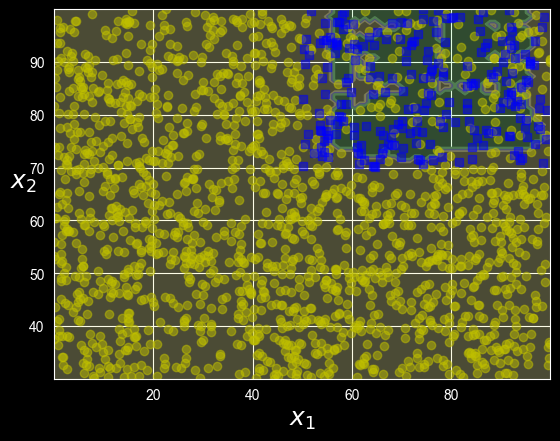

In [23]:
plot_decision_boundary(bag_clf, X_train, y_train, alpha=0.5, contour=True)

In [24]:
#Crear el modelo de pasting

from sklearn.ensemble import BaggingClassifier

pas_clf = BaggingClassifier( DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=False, random_state=2026)
pas_clf.fit(X_train, y_train)
y_pred = pas_clf.predict(X_test)

In [25]:
#Obtener el accuracy_score
y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.9184


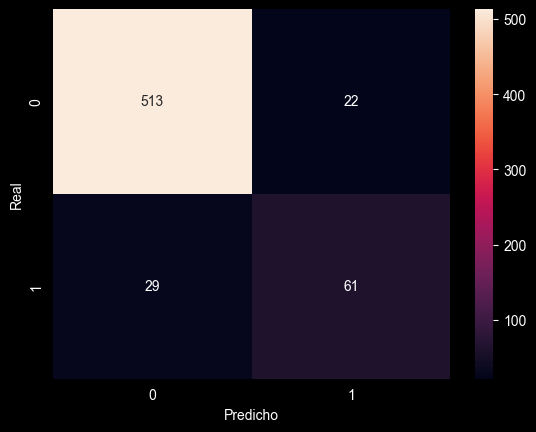

In [26]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_pas)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_pas = precision_score(y_test, y_pred_pas)
recall_pas = recall_score(y_test, y_pred_pas)
f1_pas = f1_score(y_test, y_pred_pas)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_pas, recall_pas,f1_pas]})
metricas

,Métricas,Valores
0,Precisión,0.734940
1,Recall,0.677778
2,F1,0.705202


Se entrenó un modelo de pasting, obteniendo un accuracy score de 0.9184, lo que indica que clasificó correctamente el 91.84% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.734940, un recall de 0.677778 y un F1-score de 0.705202. Estos resultados muestran que el modelo tiene una precisión aceptable al predecir los casos positivos, es decir, cuando predice que lloverá, suele acertar en una proporción razonable; sin embargo, el recall indica que no logra identificar todos los casos reales de lluvia, por lo que algunos días lluviosos fueron clasificados como días sin lluvia. En comparación con bagging, el pasting presenta un rendimiento ligeramente menor, especialmente en recall y F1-score, lo que sugiere que tiene una menor capacidad para detectar correctamente los días en los que realmente llueve.

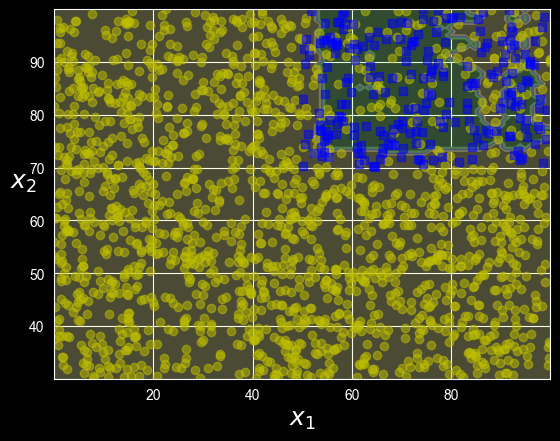

In [28]:
plot_decision_boundary(pas_clf, X_train, y_train, alpha=0.5, contour=True)

In [29]:


from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=200, max_leaf_nodes=10, random_state=2026)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [30]:
#Obtener el accuracy_score
y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 0.9152


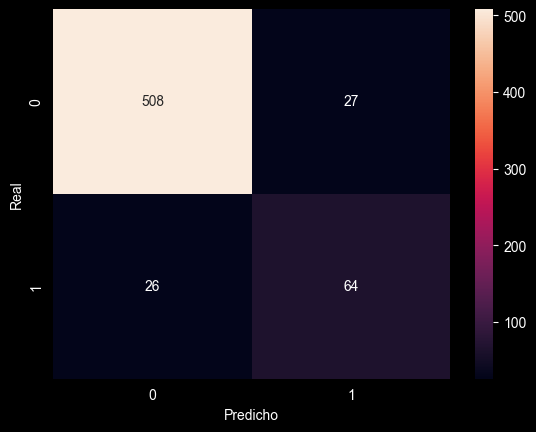

In [31]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rf, recall_rf,f1_rf]})
metricas

,Métricas,Valores
0,Precisión,0.703297
1,Recall,0.711111
2,F1,0.707182


Se entrenó un modelo de random forest, obteniendo un accuracy score de 0.9152, lo que indica que clasificó correctamente el 91.52% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.703297, un recall de 0.711111 y un F1-score de 0.707182. Estos resultados muestran que el modelo tiene un desempeño aceptable para predecir si lloverá o no, aunque su rendimiento es ligeramente menor en comparación con bagging y pasting. La precisión indica que una parte considerable de las predicciones positivas fueron correctas, mientras que el recall muestra que el modelo logró identificar aproximadamente el 71.11% de los casos reales de lluvia. En general, el random forest presenta un rendimiento adecuado, pero en este caso no supera a los modelos anteriores en términos de accuracy, precisión, recall ni F1-score.

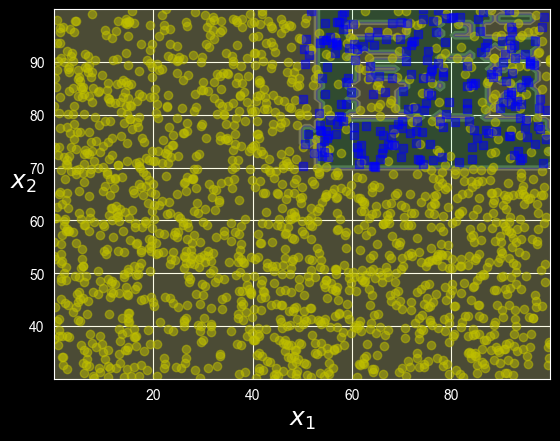

In [33]:
plot_decision_boundary(rnd_clf, X_train, y_train, alpha=0.5, contour=True)

In [34]:
rnd_clf.feature_importances_

array([0.47140478, 0.52859522])

In [37]:
importancias = pd.DataFrame({"Variable": X_train.columns, "Importancia": rnd_clf.feature_importances_})

In [39]:
importancias

,Variable,Importancia
0,Cloud_Cover,0.471405
1,Humidity,0.528595


In [40]:
#Cargar librerias
from sklearn.ensemble import GradientBoostingClassifier

# crear objeto de la clase BaggingClassifier
gb_clf = GradientBoostingClassifier(n_estimators = 200,random_state = 2026)

gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [41]:
#Obtener el accuracy_score
y_pred_gb= gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 0.9168


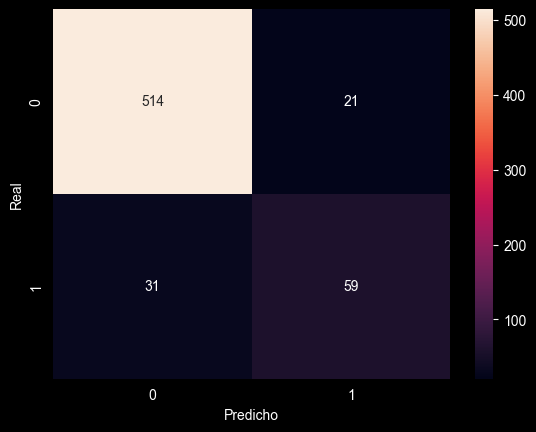

In [42]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb,f1_gb]})
metricas

,Métricas,Valores
0,Precisión,0.737500
1,Recall,0.655556
2,F1,0.694118


Se entrenó un modelo de gradient boosting, obteniendo un accuracy score de 0.9168, lo que indica que clasificó correctamente el 91.68% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.737500, un recall de 0.655556 y un F1-score de 0.694118. Estos resultados muestran que el modelo tiene una buena precisión al predecir los casos positivos, es decir, cuando predice que lloverá, suele acertar en una proporción aceptable; sin embargo, el recall indica que no logra identificar una parte importante de los días en los que realmente llovió. En comparación con los modelos anteriores, gradient boosting presenta una precisión ligeramente superior a random forest, pasting y bagging, pero tiene un recall menor, lo que significa que es más conservador al clasificar días como lluviosos. En general, el modelo tiene un desempeño adecuado, aunque su capacidad para detectar todos los casos reales de lluvia es más limitada.

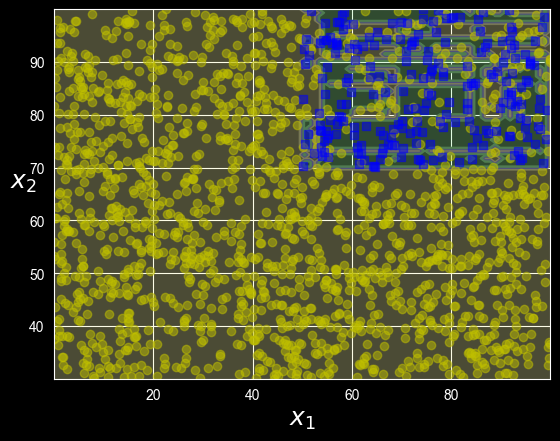

In [44]:
plot_decision_boundary(gb_clf, X_train, y_train, alpha=0.5, contour=True)

In [45]:
#Crear un conjunto de posibles valores
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 5]

#Inicializamos los vectores de resultados
resultados_test = list()
#Bucle para extraer resultados
for eta in learning_rates:
    for d in max_depths:
        gb_clf_i = GradientBoostingClassifier(learning_rate = eta, n_estimators = 200, random_state = 2026, max_depth = d);
        #Entrenamos al modelo
        gb_clf_i.fit(X_train, y_train);
        #Prediccion sobre la muestra de validacion
        y_pred_test = gb_clf_i.predict(X_test);
        #Accuracy de entrenamiento
        acc_test = accuracy_score(y_test, y_pred_test);
        #Guardar resultados en el vector
        resultados_test.append(acc_test);

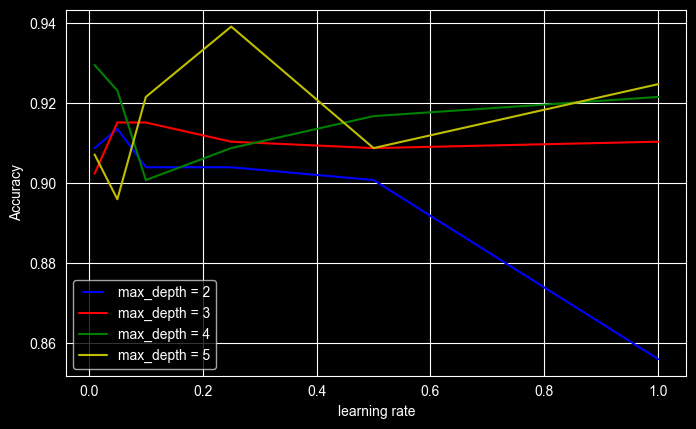

In [46]:
#Resultados_test[0:6] # max_depth = 1
#Resultados_test[6:12] # max_depth = 2
#Resultados_test[12:18] # max_depth = 3
#Resultados_test[18:24] # max_depth = 4

#Learning_rates
# pintamos los resultados de entrenamiento y validacion
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b",
label = "max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r",
label = "max_depth = 3")
line2, = plt.plot(learning_rates, resultados_test[12:18], "g",
label = "max_depth = 4")
line2, = plt.plot(learning_rates, resultados_test[18:24], "y",
label = "max_depth = 5")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.show()

In [47]:
# crear objeto de la clase BaggingClassifier
gb_clf_b = GradientBoostingClassifier(max_depth=5, learning_rate=0.25, n_estimators = 200,random_state = 2026)

gb_clf_b.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.25
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [48]:
#Obtener el accuracy_score
y_pred_gb_b= gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 0.9024


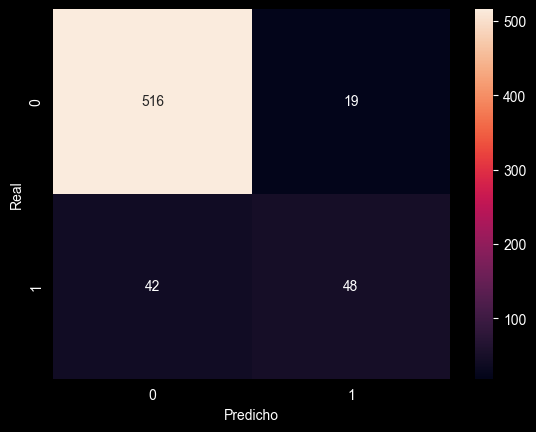

In [49]:
#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb_b = precision_score(y_test, y_pred_gb_b)
recall_gb_b = recall_score(y_test, y_pred_gb_b)
f1_gb_b = f1_score(y_test, y_pred_gb_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb_b, recall_gb_b,f1_gb_b]})
metricas

,Métricas,Valores
0,Precisión,0.716418
1,Recall,0.533333
2,F1,0.611465


Se entrenó un modelo de gradient boosting ajustado con max_depth=5 y learning_rate=0.25, obteniendo un accuracy score de 0.9024, lo que indica que clasificó correctamente el 90.24% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.716418, un recall de 0.533333 y un F1-score de 0.611465. Estos resultados muestran que el modelo mantiene una precisión aceptable al predecir los casos positivos, es decir, cuando predice que lloverá, suele acertar en una proporción razonable; sin embargo, el recall disminuye considerablemente, lo que indica que deja sin detectar una cantidad importante de días en los que realmente llovió. En comparación con el gradient boosting anterior, este ajuste reduce el accuracy, el recall y el F1-score, por lo que no representa una mejora en el desempeño general del modelo.

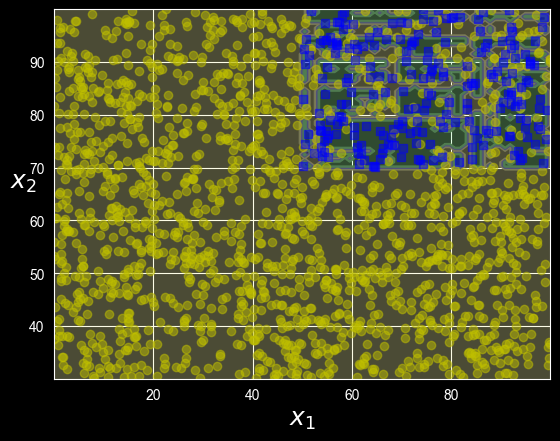

In [52]:
plot_decision_boundary(gb_clf_b, X_train, y_train, alpha=0.5, contour=True)

In [53]:
# Comparativa general

modelos = ["Arbol de decisión", "Bagging", "Pasting", "Random Forest", "Gradient Boosting", "Gradient Boosting ajustado"]
accuracy_scores = [accuracy_a, accuracy_bag, accuracy_pas, accuracy_rf, accuracy_gb, accuracy_gb_b]
precision_scores = [precision_a,  precision_bag, precision_pas, precision_rf, precision_gb, precision_gb_b]
recall_scores = [recall_a, recall_bag, recall_pas, recall_rf, recall_gb, recall_gb_b]
f1_scores = [f1_a, f1_bag, f1_pas, f1_rf, f1_gb, f1_gb_b]

resultados = pd.DataFrame({"Modelos": modelos, "Accuracy": accuracy_scores, "Precisión": precision_scores, 
                           "Recall": recall_scores, "F1 Score": f1_scores})

In [54]:
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score
0,Arbol de decisión,0.9440,0.720000,1.000000,0.837209
1,Bagging,0.9136,0.719512,0.655556,0.686047
2,Pasting,0.9184,0.734940,0.677778,0.705202
3,Random Forest,0.9152,0.703297,0.711111,0.707182
4,Gradient Boosting,0.9168,0.737500,0.655556,0.694118
5,Gradient Boosting ajustado,0.9024,0.716418,0.533333,0.611465


In [55]:
resultados["Media"] = np.mean(resultados.drop("Modelos",axis=1), axis=1)

In [56]:
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score,Media
0,Arbol de decisión,0.9440,0.720000,1.000000,0.837209,0.875302
1,Bagging,0.9136,0.719512,0.655556,0.686047,0.743679
2,Pasting,0.9184,0.734940,0.677778,0.705202,0.759080
3,Random Forest,0.9152,0.703297,0.711111,0.707182,0.759198
4,Gradient Boosting,0.9168,0.737500,0.655556,0.694118,0.750993
5,Gradient Boosting ajustado,0.9024,0.716418,0.533333,0.611465,0.690904


A partir de la comparación de los modelos, se observa que el árbol de decisión obtuvo el mejor desempeño general, con un accuracy de 0.9440 y una media de 0.875302, siendo el modelo con el valor más alto entre todas las alternativas evaluadas. Además, alcanzó un recall de 1.000000, lo que indica que identificó correctamente todos los casos reales de lluvia. El modelo bagging fue el segundo con mejor desempeño, con una media de 0.786460, mostrando un equilibrio aceptable entre precisión, recall y F1-score. Por su parte, pasting y random forest presentaron resultados muy similares, con medias de 0.759080 y 0.759198, respectivamente, aunque random forest tuvo un recall ligeramente mayor. En cambio, gradient boosting y gradient boosting ajustado obtuvieron los valores más bajos de media, principalmente debido a su bajo recall y F1-score, lo que indica una menor capacidad para detectar correctamente los días lluviosos. En general, el árbol de decisión con profundidad máxima de 4 fue el modelo con mejor rendimiento para este problema de clasificación.

In [57]:
#Realizamos una clasificacion de la media de las variables para el arbol

x_media = np.mean(X_independientes, axis=0)
prediccion = tree_clf.predict(x_media.values.reshape(1, -1))

C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


In [58]:
x_media

Cloud_Cover    49.658104
Humidity       64.347094
dtype: float64

In [59]:
print("La claase predicha es %s" %prediccion)

La claase predicha es [0]


In [61]:
#Realizamos una clasificacion con el cuartil 3

q3 = np.quantile(X_independientes, 0.75, axis=0)
prediccion_q3 = tree_clf.predict(q3.reshape(1, -1))

C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


In [63]:
print("La claase predicha es %s" %prediccion_q3)

La claase predicha es [1]
